# 📊 Project 1 — Model Evaluation
**Tasks covered:**
- Evaluate model performance using Accuracy, Precision, Recall, F1-Score
- Visualize Confusion Matrix (raw counts + normalized)
- Generate detailed Classification Report
- ROC-AUC Curve, Precision-Recall Curve
- Feature Importance (if applicable)

---

## 1. Import Libraries

In [7]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — datasets, models, metrics
from sklearn.datasets import load_breast_cancer          # sample dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay
)

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. Load Dataset & Prepare Data
> Using **Breast Cancer** dataset (binary classification). Replace with your own dataset below.

In [8]:
# ─────────────────────────────────────────────────────────────
# 🔁  REPLACE THIS SECTION WITH YOUR OWN DATASET IF NEEDED
# Example: df = pd.read_csv('your_dataset.csv')
#          X  = df.drop('target', axis=1)
#          y  = df['target']
# ─────────────────────────────────────────────────────────────

data = load_breast_cancer()
X    = pd.DataFrame(data.data, columns=data.feature_names)
y    = pd.Series(data.target, name='target')
class_names = data.target_names          # ['malignant', 'benign']

print(f'Dataset shape  : {X.shape}')
print(f'Classes        : {class_names}')
print(f'Class distribution:\n{y.value_counts()}')
X.head()

Dataset shape  : (569, 30)
Classes        : ['malignant' 'benign']
Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# ── Train / Test Split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ── Feature Scaling ─────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 426
Testing  samples : 143


---
## 3. Train Multiple Models

In [10]:
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                    : SVC(probability=True, random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅  {name:30s} — trained')

✅  Logistic Regression            — trained
✅  Random Forest                  — trained
✅  Gradient Boosting              — trained
✅  SVM                            — trained
✅  Decision Tree                  — trained


---
## 4. Evaluate All Models — Core Metrics

In [12]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1   # rank from 1

# Style the table
styled = results_df.style \
    .background_gradient(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
                         cmap='YlGn') \
    .set_caption('📋 Model Comparison — Test Set Metrics') \
    .format(precision=4)

styled

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression,0.9860,0.9860,0.9860,0.9860,0.9977
2,SVM,0.9790,0.9792,0.9790,0.9791,0.9969
3,Random Forest,0.9580,0.9581,0.9580,0.9579,0.9951
4,Gradient Boosting,0.9580,0.9590,0.9580,0.9577,0.9925
5,Decision Tree,0.9231,0.9247,0.9231,0.9235,0.9234


---
## 5. Confusion Matrices — All Models

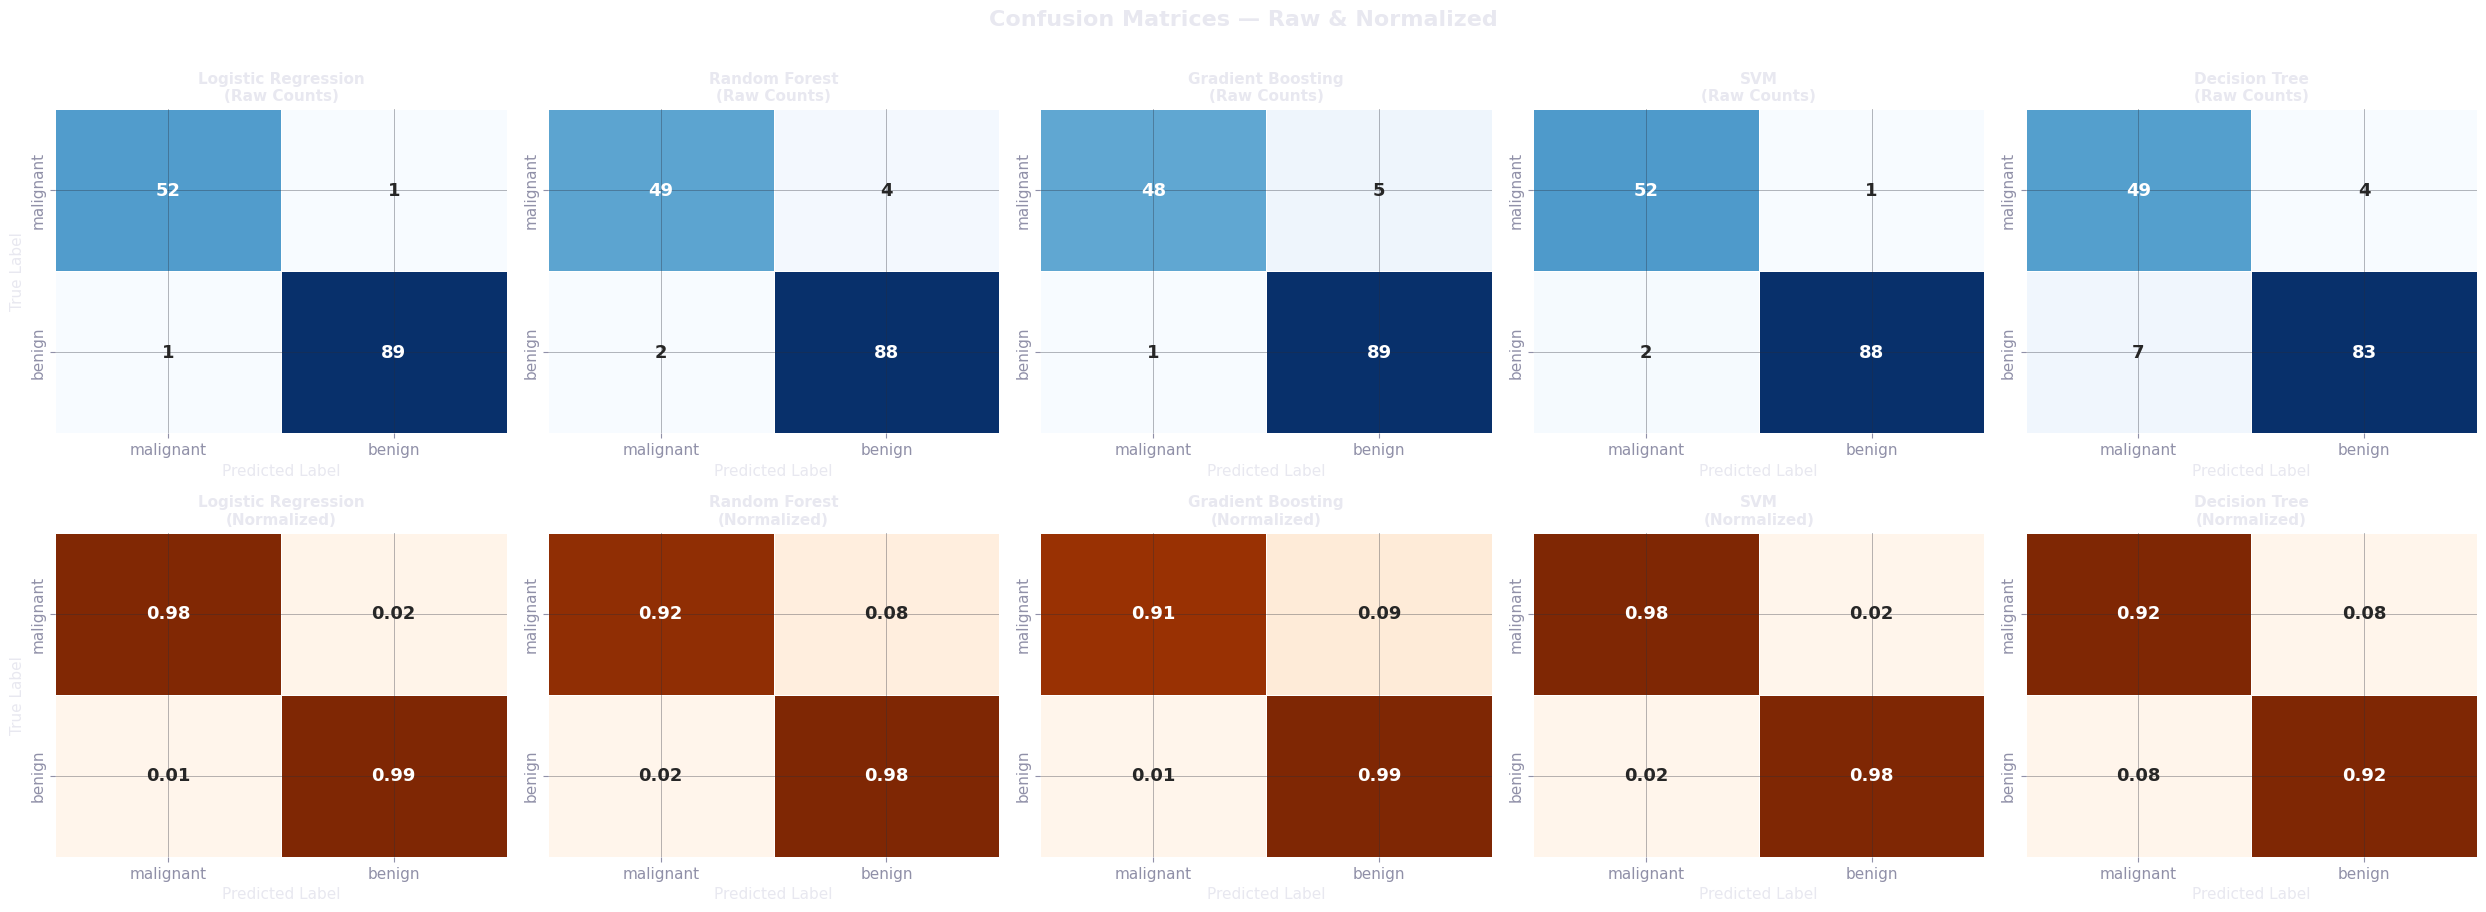


💾  Saved: confusion_matrices.png


In [13]:
n_models = len(trained_models)
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))
fig.suptitle('Confusion Matrices — Raw & Normalized', fontsize=16, fontweight='bold', y=1.01)

for col, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cm_n   = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalize

    # ── Raw counts ──────────────────────────────────────────
    ax1 = axes[0, col]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax1, cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax1.set_title(f'{name}\n(Raw Counts)', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label' if col == 0 else '')

    # ── Normalized ──────────────────────────────────────────
    ax2 = axes[1, col]
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax2, cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax2.set_title(f'{name}\n(Normalized)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label' if col == 0 else '')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: confusion_matrices.png')

---
## 6. Classification Reports

In [14]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print('=' * 55)
    print(f'  📌  {name}')
    print('=' * 55)
    print(classification_report(y_test, y_pred, target_names=class_names))

  📌  Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

  📌  Random Forest
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

  📌  Gradient Boosting
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighte

---
## 7. Visualize Classification Report as Heatmap

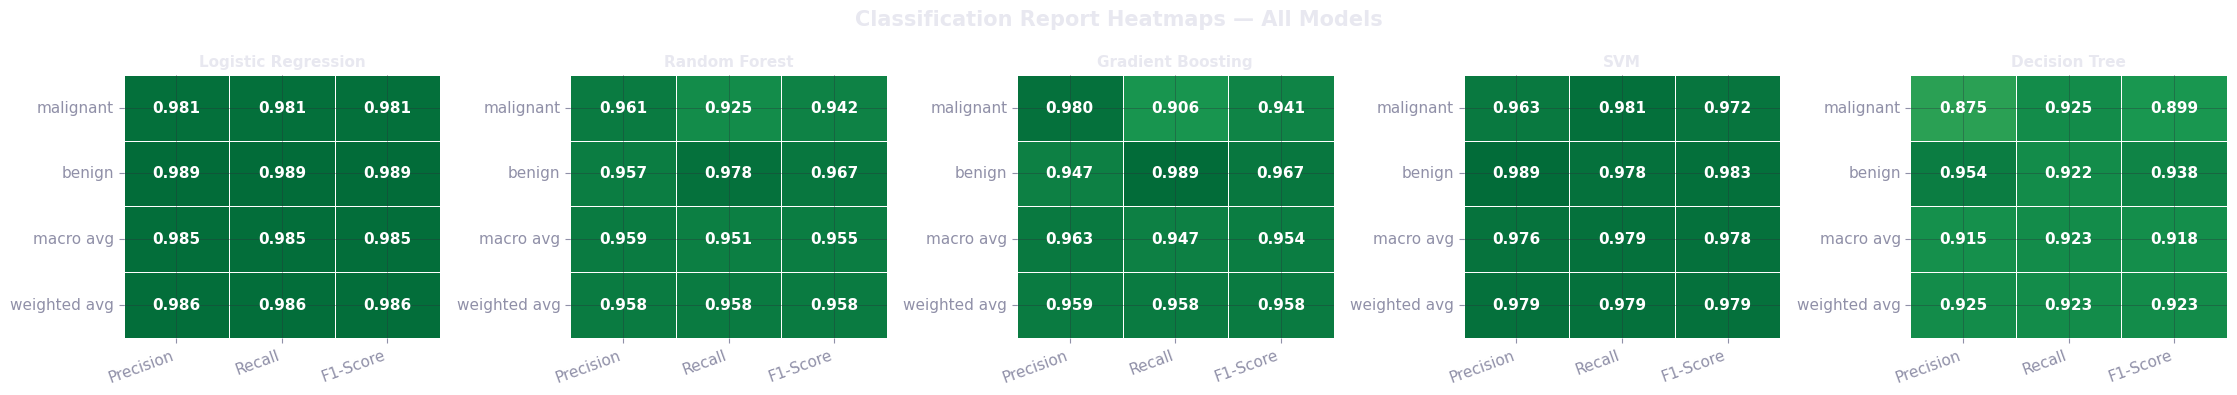


💾  Saved: classification_reports.png


In [15]:
def plot_classification_report(y_true, y_pred, model_name, class_names, ax):
    """Plot classification report as a heatmap."""
    report = classification_report(y_true, y_pred,
                                   target_names=class_names,
                                   output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    # Keep only class rows + macro avg
    rows = list(class_names) + ['macro avg', 'weighted avg']
    df_report = df_report.loc[rows, ['precision', 'recall', 'f1-score']]

    sns.heatmap(df_report.astype(float), annot=True, fmt='.3f',
                cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, cbar=False,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], rotation=20, ha='right')


n_models = len(trained_models)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))
fig.suptitle('Classification Report Heatmaps — All Models', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    plot_classification_report(y_test, y_pred, name, class_names, ax)

plt.tight_layout()
plt.savefig('classification_reports.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: classification_reports.png')

---
## 8. ROC-AUC Curves

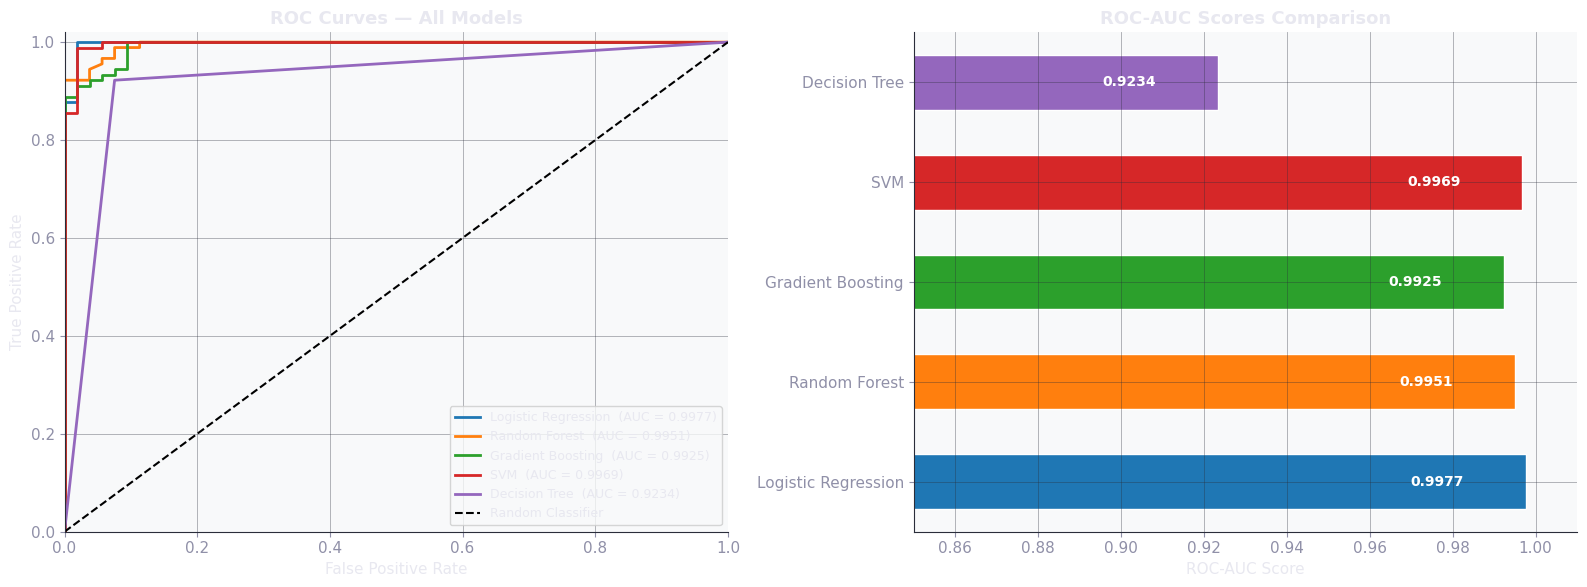


💾  Saved: roc_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10.colors

# ── Individual ROC curves ────────────────────────────────────
ax1 = axes[0]
for i, (name, model) in enumerate(trained_models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, color=colors[i],
             label=f'{name}  (AUC = {roc_auc:.4f})')

ax1.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — All Models', fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])

# ── AUC bar chart ────────────────────────────────────────────
ax2 = axes[1]
names_list = list(trained_models.keys())
auc_scores = []
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, y_prob))

bars = ax2.barh(names_list, auc_scores, color=colors[:len(names_list)],
                edgecolor='white', height=0.55)
for bar, score in zip(bars, auc_scores):
    ax2.text(bar.get_width() - 0.015, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', ha='right',
             color='white', fontweight='bold', fontsize=10)
ax2.set_xlim([0.85, 1.01])
ax2.set_xlabel('ROC-AUC Score')
ax2.set_title('ROC-AUC Scores Comparison', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: roc_curves.png')

---
## 9. Precision-Recall Curves

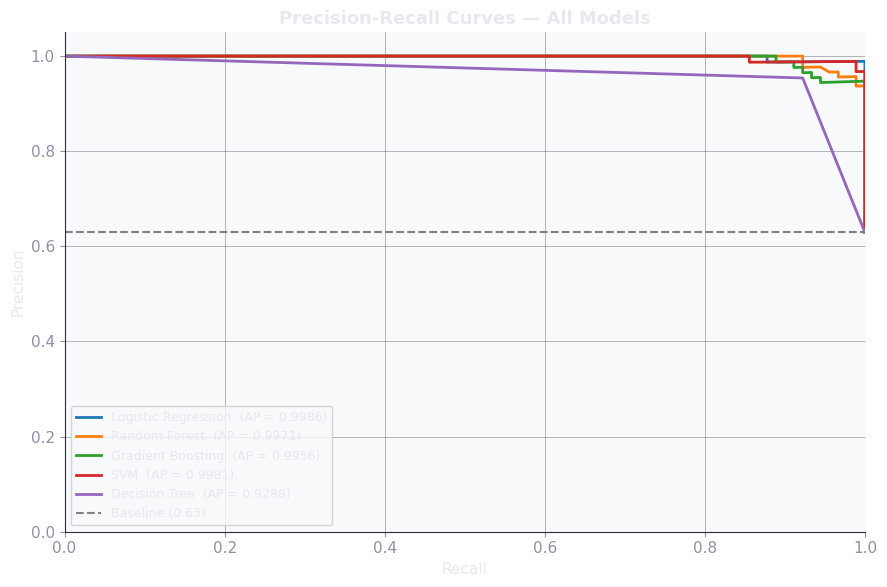


💾  Saved: precision_recall_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, model) in enumerate(trained_models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    ax.plot(recall_vals, precision_vals, lw=2, color=colors[i],
            label=f'{name}  (AP = {avg_prec:.4f})')

# Baseline (random)
no_skill = y_test.sum() / len(y_test)
ax.axhline(y=no_skill, color='gray', linestyle='--', lw=1.5, label=f'Baseline ({no_skill:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: precision_recall_curves.png')

---
## 10. Metrics Bar Chart — Side-by-Side Comparison

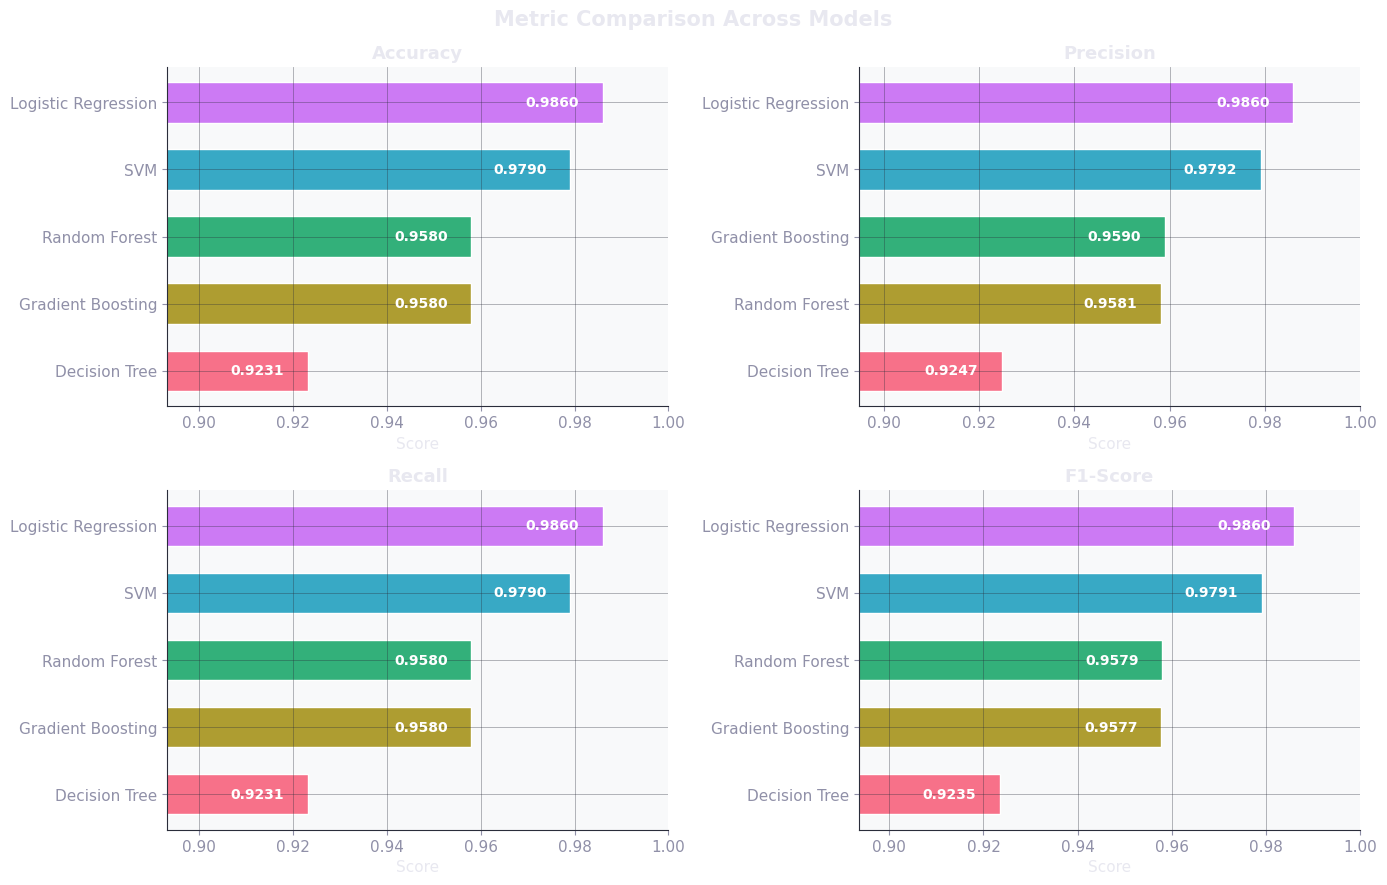


💾  Saved: metrics_comparison.png


In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_plot = results_df.set_index('Model')[metrics]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Metric Comparison Across Models', fontsize=15, fontweight='bold')

palette = sns.color_palette('husl', len(df_plot))

for ax, metric in zip(axes.flat, metrics):
    vals = df_plot[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=palette,
                   edgecolor='white', height=0.6)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right',
                color='white', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim([df_plot[metric].min() - 0.03, 1.0])
    ax.set_xlabel('Score')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: metrics_comparison.png')

---
## 11. Feature Importance (Random Forest)

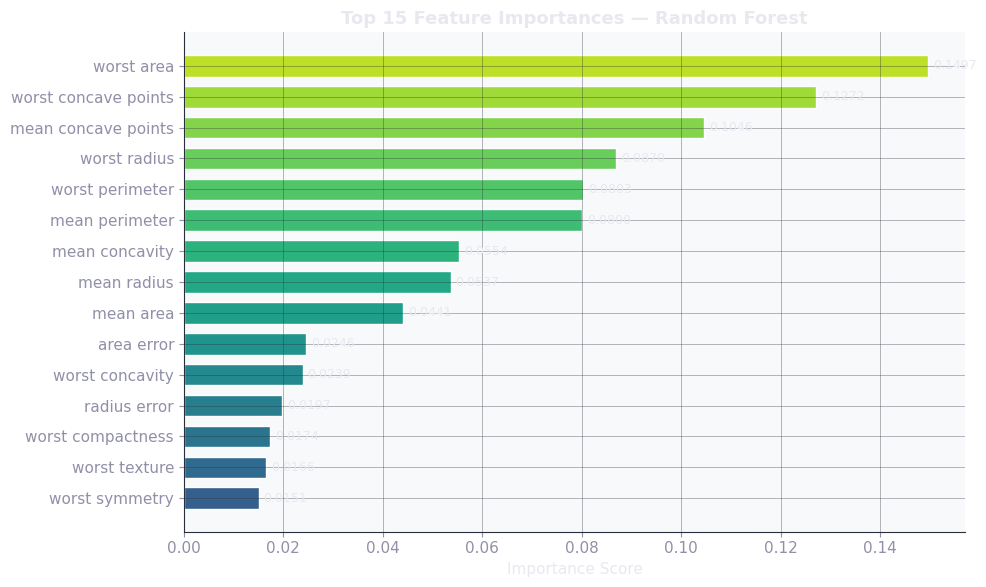


💾  Saved: feature_importance.png


In [19]:
rf_model    = trained_models['Random Forest']
importances = rf_model.feature_importances_
feat_names  = data.feature_names   # replace with X.columns if using own data

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_df)))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_feat, edgecolor='white', height=0.7)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: feature_importance.png')

---
## 12. Best Model — Detailed Deep Dive

In [20]:
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test)
y_prob_best     = best_model.predict_proba(X_test)[:, 1]

print(f'🏆  Best Model : {best_model_name}')
print(f'    F1-Score   : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'    ROC-AUC    : {roc_auc_score(y_test, y_prob_best):.4f}')
print()
print('─' * 50)
print('Full Classification Report:')
print('─' * 50)
print(classification_report(y_test, y_pred_best, target_names=class_names))

🏆  Best Model : Logistic Regression
    F1-Score   : 0.9860
    ROC-AUC    : 0.9977

──────────────────────────────────────────────────
Full Classification Report:
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



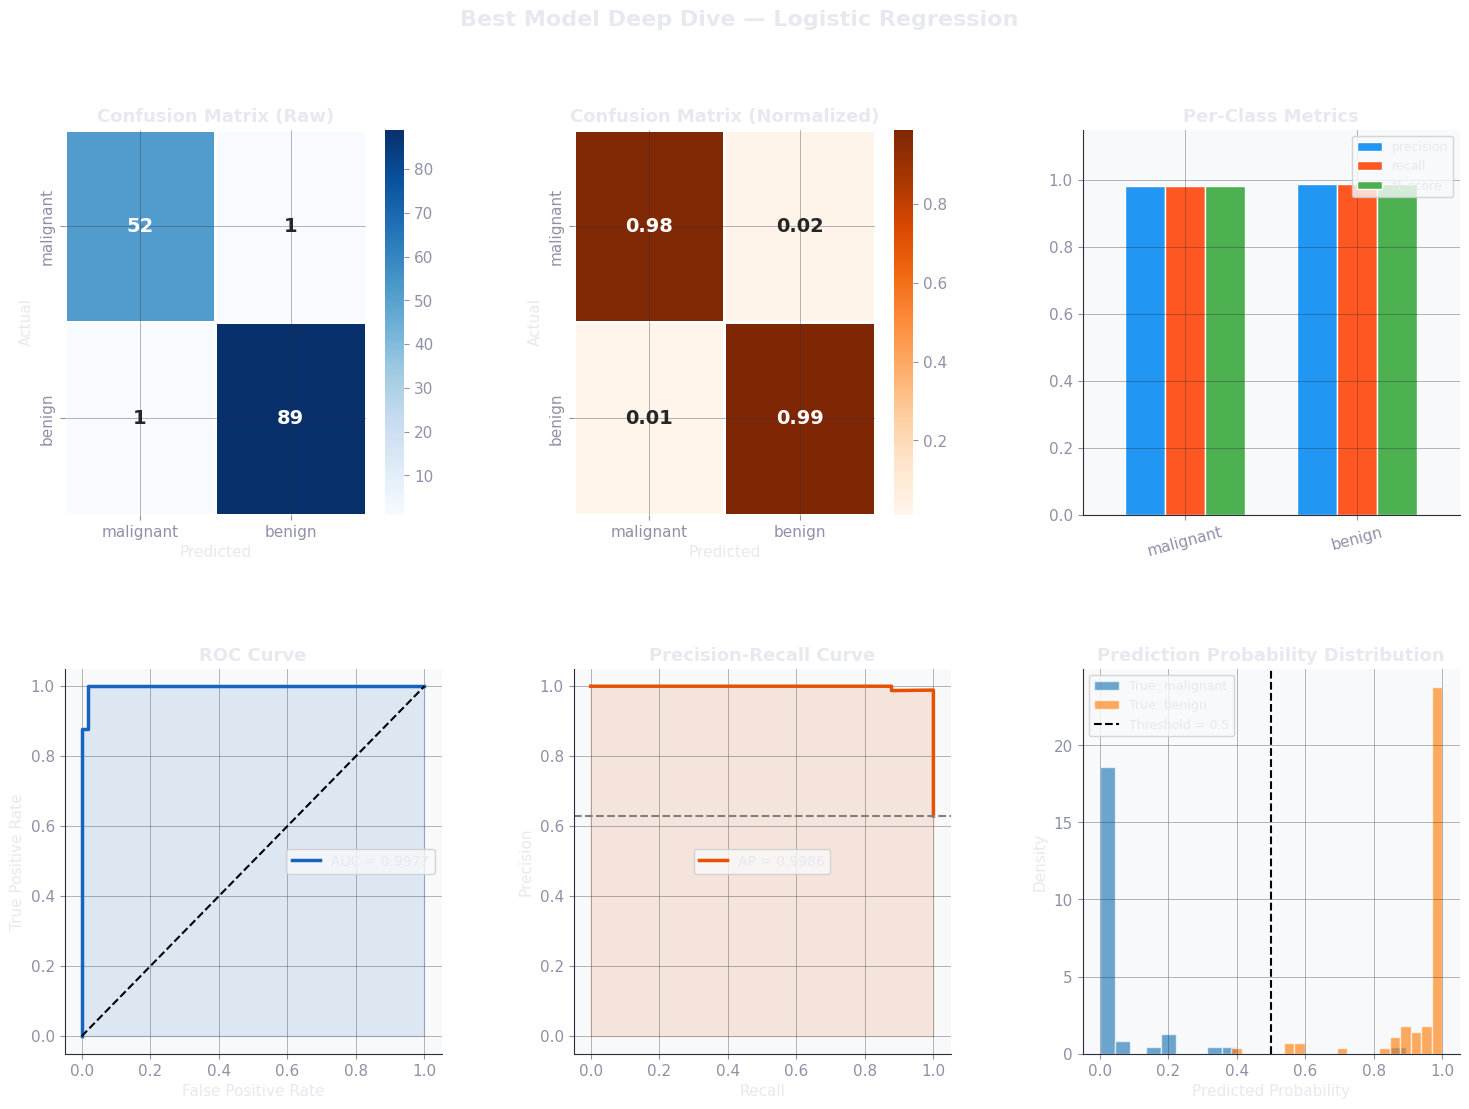


💾  Saved: best_model_dashboard.png


In [21]:
# ── Combined dashboard for best model ───────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle(f'Best Model Deep Dive — {best_model_name}',
             fontsize=16, fontweight='bold')

# 1. Raw Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax1, linewidths=1, cbar=True,
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (Raw)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# 2. Normalized Confusion Matrix
ax2  = fig.add_subplot(gs[0, 1])
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax2, linewidths=1, cbar=True,
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

# 3. Per-class metrics
ax3     = fig.add_subplot(gs[0, 2])
report  = classification_report(y_test, y_pred_best,
                                 target_names=class_names, output_dict=True)
df_r    = pd.DataFrame(report).T.loc[list(class_names), ['precision','recall','f1-score']]
df_r.plot(kind='bar', ax=ax3, color=['#2196F3','#FF5722','#4CAF50'],
          edgecolor='white', width=0.7)
ax3.set_title('Per-Class Metrics', fontweight='bold')
ax3.set_xticklabels(class_names, rotation=15)
ax3.set_ylim([0, 1.15])
ax3.legend(fontsize=9)

# 4. ROC Curve
ax4 = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc_val = auc(fpr, tpr)
ax4.plot(fpr, tpr, lw=2.5, color='#1565C0', label=f'AUC = {roc_auc_val:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5)
ax4.fill_between(fpr, tpr, alpha=0.12, color='#1565C0')
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.legend(fontsize=10)

# 5. Precision-Recall Curve
ax5 = fig.add_subplot(gs[1, 1])
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob_best)
avg_prec = average_precision_score(y_test, y_prob_best)
ax5.plot(rec_vals, prec_vals, lw=2.5, color='#E65100', label=f'AP = {avg_prec:.4f}')
ax5.axhline(y=no_skill, color='gray', linestyle='--', lw=1.5)
ax5.fill_between(rec_vals, prec_vals, alpha=0.12, color='#E65100')
ax5.set_xlabel('Recall'); ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold')
ax5.legend(fontsize=10)

# 6. Probability Distribution
ax6 = fig.add_subplot(gs[1, 2])
for idx, cls in enumerate(class_names):
    mask = y_test == idx
    ax6.hist(y_prob_best[mask], bins=20, alpha=0.65,
             label=f'True: {cls}', density=True,
             color=colors[idx], edgecolor='white')
ax6.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
ax6.set_xlabel('Predicted Probability'); ax6.set_ylabel('Density')
ax6.set_title('Prediction Probability Distribution', fontweight='bold')
ax6.legend(fontsize=9)

plt.savefig('best_model_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾  Saved: best_model_dashboard.png')

---
## 13. Summary & Conclusion

In [22]:
print('=' * 60)
print('           📊  FINAL MODEL EVALUATION SUMMARY')
print('=' * 60)
print(results_df.to_string(index=True))
print()
print(f'🏆  Best Model   : {best_model_name}')
print(f'    Accuracy     : {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'    Precision    : {results_df.iloc[0]["Precision"]:.4f}')
print(f'    Recall       : {results_df.iloc[0]["Recall"]:.4f}')
print(f'    F1-Score     : {results_df.iloc[0]["F1-Score"]:.4f}')
print(f'    ROC-AUC      : {results_df.iloc[0]["ROC-AUC"]:.4f}')
print()
print('📂  Saved plots:')
for f in ['confusion_matrices.png', 'classification_reports.png',
          'roc_curves.png', 'precision_recall_curves.png',
          'metrics_comparison.png', 'feature_importance.png',
          'best_model_dashboard.png']:
    print(f'    • {f}')
print('=' * 60)

           📊  FINAL MODEL EVALUATION SUMMARY
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1  Logistic Regression    0.9860     0.9860  0.9860    0.9860   0.9977
2                  SVM    0.9790     0.9792  0.9790    0.9791   0.9969
3        Random Forest    0.9580     0.9581  0.9580    0.9579   0.9951
4    Gradient Boosting    0.9580     0.9590  0.9580    0.9577   0.9925
5        Decision Tree    0.9231     0.9247  0.9231    0.9235   0.9234

🏆  Best Model   : Logistic Regression
    Accuracy     : 0.9860
    Precision    : 0.9860
    Recall       : 0.9860
    F1-Score     : 0.9860
    ROC-AUC      : 0.9977

📂  Saved plots:
    • confusion_matrices.png
    • classification_reports.png
    • roc_curves.png
    • precision_recall_curves.png
    • metrics_comparison.png
    • feature_importance.png
    • best_model_dashboard.png


---
### 📝 Notes
| Metric | Best for |
|--------|----------|
| **Accuracy** | Balanced datasets |
| **Precision** | Minimizing false positives (e.g., spam detection) |
| **Recall** | Minimizing false negatives (e.g., disease detection) |
| **F1-Score** | Imbalanced datasets — balances Precision & Recall |
| **ROC-AUC** | Overall ranking ability across all thresholds |
| **PR-AUC** | Imbalanced datasets — focuses on positive class |

> 💡 **Tip:** Replace the dataset loading block in **Section 2** with your own `pd.read_csv()` to evaluate on any custom dataset.